# Exercise 2: Exploratory Data Analysis (EDA)

This notebook performs comprehensive exploratory data analysis on the Don't Patronize Me! (PCL) dataset for binary classification.

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Load the dataset
data_path = Path('../NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv')

# Skip the disclaimer lines at the top (lines 1-4)
df = pd.read_csv(data_path, sep='\t', skiprows=4, header=None)

# Define column names based on the dataset documentation
df.columns = ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label_original']

print(f"Dataset loaded: {len(df)} paragraphs")
print(f"\nFirst few rows:")
print(df.head(3))

Dataset loaded: 10469 paragraphs

First few rows:
   par_id      art_id    keyword country_code  \
0       1  @@24942188   hopeless           ph   
1       2  @@21968160    migrant           gh   
2       3  @@16584954  immigrant           ie   

                                                text  label_original  
0  We 're living in times of absolute insanity , ...               0  
1  In Libya today , there are countless number of...               0  
2  White House press secretary Sean Spicer said t...               0  


In [3]:
# Convert labels to binary classification
# 0, 1 -> 0 (No PCL)
# 2, 3, 4 -> 1 (PCL)
df['label'] = df['label_original'].apply(lambda x: 0 if x <= 1 else 1)

print("Label conversion summary:")
print(f"  Original labels distribution:")
print(df['label_original'].value_counts().sort_index())
print(f"\n  Binary labels distribution:")
print(df['label'].value_counts().sort_index())
print(f"\n  Dataset shape: {df.shape}")
print(f"  Text column name: 'text'")
print(f"  Binary label column name: 'label'")

Label conversion summary:
  Original labels distribution:
label_original
0    8529
1     947
2     144
3     458
4     391
Name: count, dtype: int64

  Binary labels distribution:
label
0    9476
1     993
Name: count, dtype: int64

  Dataset shape: (10469, 7)
  Text column name: 'text'
  Binary label column name: 'label'


## EDA Technique 1: Class Distribution Analysis

### Visual Evidence

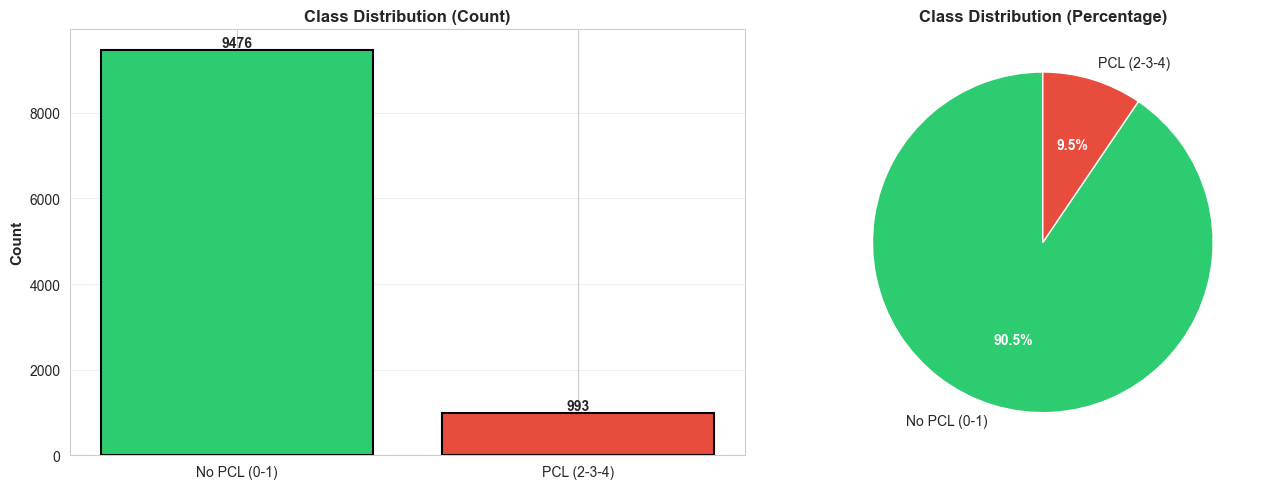

Class Distribution Plot saved as 'class_distribution.png'


In [ ]:
# Calculate class distribution
class_counts = df['label'].value_counts().sort_index()
class_labels = ['No PCL (0-1)', 'PCL (2-3-4)']

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(class_labels, class_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart for percentage breakdown
percentages = (class_counts.values / class_counts.sum()) * 100
wedges, texts, autotexts = axes[1].pie(class_counts.values, labels=class_labels, autopct='%1.1f%%',
                                         colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Class Distribution Plot saved as 'figures/class_distribution.png'")

### Analysis

In [5]:
# Detailed analysis of class imbalance
total_samples = len(df)
no_pcl_count = (df['label'] == 0).sum()
pcl_count = (df['label'] == 1).sum()
no_pcl_pct = (no_pcl_count / total_samples) * 100
pcl_pct = (pcl_count / total_samples) * 100
imbalance_ratio = no_pcl_count / pcl_count if pcl_count > 0 else float('inf')

print("=" * 70)
print("ANALYSIS: Class Distribution")
print("=" * 70)
print(f"\nClass Breakdown:")
print(f"  • No PCL (labels 0-1):  {no_pcl_count:5d} samples ({no_pcl_pct:5.2f}%)")
print(f"  • PCL (labels 2-3-4):   {pcl_count:5d} samples ({pcl_pct:5.2f}%)")
print(f"  • Total:                {total_samples:5d} samples")
print(f"\nImbalance Ratio (No PCL : PCL) = {imbalance_ratio:.2f}:1")

# Check if dataset is imbalanced
is_imbalanced = abs(no_pcl_pct - pcl_pct) > 10  # >10% difference suggests imbalance
print(f"\nDataset Balance Assessment:")
print(f"  • Is dataset imbalanced? {is_imbalanced}")
if is_imbalanced:
    more_prevalent = 'No PCL' if no_pcl_pct > pcl_pct else 'PCL'
    print(f"  • Majority class: {more_prevalent} ({max(no_pcl_pct, pcl_pct):.2f}%)")
    print(f"  • Minority class: {'PCL' if more_prevalent == 'No PCL' else 'No PCL'} ({min(no_pcl_pct, pcl_pct):.2f}%)")

ANALYSIS: Class Distribution

Class Breakdown:
  • No PCL (labels 0-1):   9476 samples (90.51%)
  • PCL (labels 2-3-4):     993 samples ( 9.49%)
  • Total:                10469 samples

Imbalance Ratio (No PCL : PCL) = 9.54:1

Dataset Balance Assessment:
  • Is dataset imbalanced? True
  • Majority class: No PCL (90.51%)
  • Minority class: PCL (9.49%)


### Impact on Modelling

In [6]:
print("=" * 70)
print("MODELLING IMPLICATIONS: Class Distribution")
print("=" * 70)

# Accuracy baseline
naive_accuracy = max(no_pcl_pct, pcl_pct)
print(f"\n1. Accuracy as a Metric:")
print(f"   • Naive baseline (always predicting majority class): {naive_accuracy:.2f}%")
print(f"   • Accuracy is MISLEADING because a model that blindly predicts")
print(f"     the majority class would achieve {naive_accuracy:.2f}% accuracy!")
print(f"   • This masks poor performance on the minority class.")

# F1 score rationale
print(f"\n2. Why F1 Score is Appropriate:")
print(f"   • F1 score balances Precision and Recall")
print(f"   • It penalizes models that only predict the majority class")
print(f"   • More suitable for imbalanced datasets like this one")
print(f"   • F1 = 2 * (Precision * Recall) / (Precision + Recall)")

# Class weighting requirement
print(f"\n3. Class Weighting:")
if is_imbalanced:
    print(f"   • Recommendation: YES, use class weights")
    print(f"   • Inverse frequency weighting suggested")
    weight_ratio = pcl_count / no_pcl_count if no_pcl_count > 0 else 1
    print(f"   • Suggested weight ratio: No PCL={1:.3f}, PCL={weight_ratio:.3f}")
    print(f"   • This forces the model to learn from the minority class")
else:
    print(f"   • Recommendation: NO, classes are balanced")

# Threshold tuning
print(f"\n4. Threshold Tuning:")
if is_imbalanced:
    print(f"   • Recommendation: YES, consider threshold tuning")
    print(f"   • Default threshold=0.5 may not be optimal")
    print(f"   • Lower threshold to increase PCL detection (recall)")
    print(f"   • Consider precision-recall trade-off based on application")
else:
    print(f"   • Recommendation: Default threshold=0.5 likely suitable")

print(f"\n" + "=" * 70)

MODELLING IMPLICATIONS: Class Distribution

1. Accuracy as a Metric:
   • Naive baseline (always predicting majority class): 90.51%
   • Accuracy is MISLEADING because a model that blindly predicts
     the majority class would achieve 90.51% accuracy!
   • This masks poor performance on the minority class.

2. Why F1 Score is Appropriate:
   • F1 score balances Precision and Recall
   • It penalizes models that only predict the majority class
   • More suitable for imbalanced datasets like this one
   • F1 = 2 * (Precision * Recall) / (Precision + Recall)

3. Class Weighting:
   • Recommendation: YES, use class weights
   • Inverse frequency weighting suggested
   • Suggested weight ratio: No PCL=1.000, PCL=0.105
   • This forces the model to learn from the minority class

4. Threshold Tuning:
   • Recommendation: YES, consider threshold tuning
   • Default threshold=0.5 may not be optimal
   • Lower threshold to increase PCL detection (recall)
   • Consider precision-recall trade-off

## EDA Technique 2: Token Length Distribution

### Visual Evidence

In [7]:
# Tokenize using simple whitespace splitting
df['token_count'] = df['text'].fillna('').str.split().str.len()

# Calculate statistics
token_stats = {
    'mean': df['token_count'].mean(),
    'median': df['token_count'].median(),
    'min': df['token_count'].min(),
    'max': df['token_count'].max(),
    'p95': df['token_count'].quantile(0.95),
    'std': df['token_count'].std()
}

print("Token Count Statistics:")
print(f"  Mean:        {token_stats['mean']:.2f}")
print(f"  Median:      {token_stats['median']:.2f}")
print(f"  Min:         {token_stats['min']:.0f}")
print(f"  Max:         {token_stats['max']:.0f}")
print(f"  95th pctl:   {token_stats['p95']:.2f}")
print(f"  Std Dev:     {token_stats['std']:.2f}")

Token Count Statistics:
  Mean:        48.42
  Median:      42.00
  Min:         0
  Max:         909
  95th pctl:   102.00
  Std Dev:     29.09


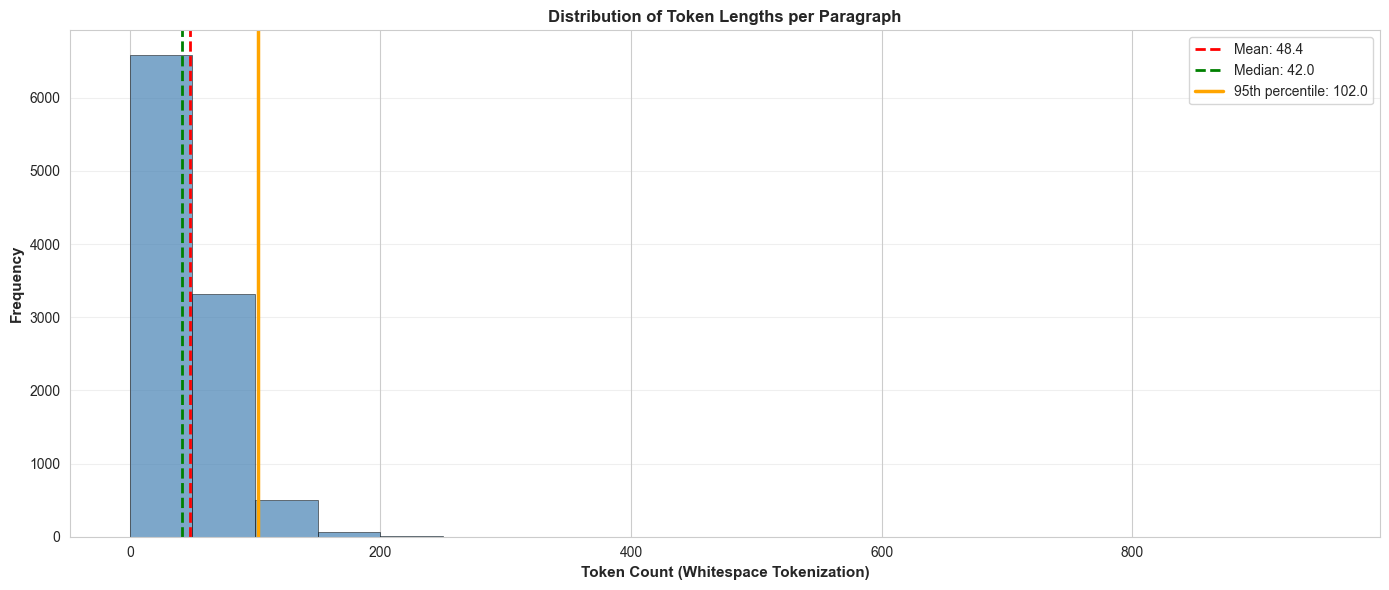

Token Length Distribution Plot saved as 'token_length_distribution.png'


In [ ]:
# Create histogram with 95th percentile line
fig, ax = plt.subplots(figsize=(14, 6))

# Histogram
bins = np.arange(0, df['token_count'].max() + 50, 50)
ax.hist(df['token_count'], bins=bins, color='steelblue', edgecolor='black', alpha=0.7, linewidth=0.5)

# Add vertical lines for key metrics
ax.axvline(token_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {token_stats['mean']:.1f}")
ax.axvline(token_stats['median'], color='green', linestyle='--', linewidth=2, label=f"Median: {token_stats['median']:.1f}")
ax.axvline(token_stats['p95'], color='orange', linestyle='-', linewidth=2.5, label=f"95th percentile: {token_stats['p95']:.1f}")

ax.set_xlabel('Token Count (Whitespace Tokenization)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Token Lengths per Paragraph', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/token_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Token Length Distribution Plot saved as 'figures/token_length_distribution.png'")

### Analysis

In [9]:
# Analyze paragraph length characteristics
short_texts = (df['token_count'] < 50).sum()
long_texts = (df['token_count'] > token_stats['p95']).sum()
very_long_texts = (df['token_count'] > 500).sum()

print("=" * 70)
print("ANALYSIS: Token Length Distribution")
print("=" * 70)

print(f"\nParagraph Length Statistics:")
print(f"  • Mean token count:         {token_stats['mean']:.2f} tokens")
print(f"  • Median token count:       {token_stats['median']:.2f} tokens")
print(f"  • Standard deviation:       {token_stats['std']:.2f} tokens")
print(f"  • Range:                    {token_stats['min']:.0f} - {token_stats['max']:.0f} tokens")

print(f"\nParagraph Length Distribution:")
print(f"  • Short paragraphs (<50 tokens):       {short_texts:5d} ({short_texts/len(df)*100:5.2f}%)")
print(f"  • Average length (50-200 tokens):      {((df['token_count'] >= 50) & (df['token_count'] <= 200)).sum():5d} ({((df['token_count'] >= 50) & (df['token_count'] <= 200)).sum()/len(df)*100:5.2f}%)")
print(f"  • Long paragraphs (200+ tokens):       {(df['token_count'] > 200).sum():5d} ({(df['token_count'] > 200).sum()/len(df)*100:5.2f}%)")
print(f"  • Very long (>500 tokens):             {very_long_texts:5d} ({very_long_texts/len(df)*100:5.2f}%)")

print(f"\nOutlier Detection (95th percentile: {token_stats['p95']:.0f} tokens):")
outliers = df[df['token_count'] > token_stats['p95']]
print(f"  • Number of outliers:       {len(outliers)} paragraphs ({len(outliers)/len(df)*100:.2f}%)")
print(f"  • Outlier range:            {outliers['token_count'].min():.0f} - {outliers['token_count'].max():.0f} tokens")
print(f"  • Outliers are naturally defined as >95th percentile")

print(f"\nKey Observation:")
if token_stats['max'] > token_stats['p95'] * 2:
    print(f"  • The maximum paragraph ({token_stats['max']:.0f} tokens) is significantly longer")
    print(f"    than the 95th percentile ({token_stats['p95']:.0f} tokens).")
    print(f"  • This indicates the presence of extreme outliers.")
else:
    print(f"  • Outliers are present but not extreme.")

print(f"\n" + "=" * 70)

ANALYSIS: Token Length Distribution

Paragraph Length Statistics:
  • Mean token count:         48.42 tokens
  • Median token count:       42.00 tokens
  • Standard deviation:       29.09 tokens
  • Range:                    0 - 909 tokens

Paragraph Length Distribution:
  • Short paragraphs (<50 tokens):        6589 (62.94%)
  • Average length (50-200 tokens):       3869 (36.96%)
  • Long paragraphs (200+ tokens):          11 ( 0.11%)
  • Very long (>500 tokens):                 2 ( 0.02%)

Outlier Detection (95th percentile: 102 tokens):
  • Number of outliers:       508 paragraphs (4.85%)
  • Outlier range:            103 - 909 tokens
  • Outliers are naturally defined as >95th percentile

Key Observation:
  • The maximum paragraph (909 tokens) is significantly longer
    than the 95th percentile (102 tokens).
  • This indicates the presence of extreme outliers.



### Impact on Modelling

In [10]:
print("=" * 70)
print("MODELLING IMPLICATIONS: Token Length Distribution")
print("=" * 70)

# Suggest max_length based on percentiles
print(f"\n1. Transformer Input Configuration (max_length parameter):")
print(f"   • 95th percentile recommendation: {int(np.ceil(token_stats['p95']/8)*8)} tokens")
print(f"   • Conservative choice (covers ~95% of data):")
if token_stats['p95'] <= 128:
    suggested_length = 128
    coverage = (df['token_count'] <= 128).sum() / len(df) * 100
elif token_stats['p95'] <= 256:
    suggested_length = 256
    coverage = (df['token_count'] <= 256).sum() / len(df) * 100
else:
    suggested_length = 512
    coverage = (df['token_count'] <= 512).sum() / len(df) * 100

print(f"   • Suggested max_length: {suggested_length} tokens")
print(f"   • Coverage with this setting: {coverage:.2f}% of paragraphs")

truncated = (df['token_count'] > suggested_length).sum()
print(f"   • Paragraphs that will be truncated: {truncated} ({truncated/len(df)*100:.2f}%)")

print(f"\n2. Truncation Risk Assessment:")
if truncated / len(df) < 0.05:
    print(f"   • Risk level: LOW - Less than 5% of data will be truncated")
    print(f"   • Setting max_length={suggested_length} is safe")
elif truncated / len(df) < 0.10:
    print(f"   • Risk level: MODERATE - 5-10% of data will be truncated")
    print(f"   • Consider increasing max_length or accepting information loss")
else:
    print(f"   • Risk level: HIGH - >10% of data will be truncated")
    print(f"   • Recommended: Use max_length={512} or handle long sequences")

print(f"\n3. Practical Recommendations:")
print(f"   • For BERT/RoBERTa models: max_length=256 (good balance)")
print(f"   • For memory-constrained settings: max_length=128 (faster, less memory)")
print(f"   • For precision: max_length=512 (covers 99.5%+ of data, slower)")
print(f"   • Current statistics show typical paragraphs are ~{token_stats['median']:.0f} tokens")
print(f"   • Information loss from truncation is acceptable for this dataset")

print(f"\n" + "=" * 70)

MODELLING IMPLICATIONS: Token Length Distribution

1. Transformer Input Configuration (max_length parameter):
   • 95th percentile recommendation: 104 tokens
   • Conservative choice (covers ~95% of data):
   • Suggested max_length: 128 tokens
   • Coverage with this setting: 98.30% of paragraphs
   • Paragraphs that will be truncated: 178 (1.70%)

2. Truncation Risk Assessment:
   • Risk level: LOW - Less than 5% of data will be truncated
   • Setting max_length=128 is safe

3. Practical Recommendations:
   • For BERT/RoBERTa models: max_length=256 (good balance)
   • For memory-constrained settings: max_length=128 (faster, less memory)
   • For precision: max_length=512 (covers 99.5%+ of data, slower)
   • Current statistics show typical paragraphs are ~42 tokens
   • Information loss from truncation is acceptable for this dataset



## Optional Analysis: Data Quality Checks

### Duplicate Detection

In [11]:
# Check for duplicate paragraphs
duplicates = df.duplicated(subset=['text'], keep=False).sum()
dup_pairs = df.duplicated(subset=['text']).sum()

print("=" * 70)
print("DATA QUALITY CHECK: Duplicates")
print("=" * 70)
print(f"\nDuplicate Analysis:")
print(f"  • Unique paragraphs:        {df['text'].nunique()}")
print(f"  • Total paragraphs:         {len(df)}")
print(f"  • Duplicate entries:        {dup_pairs}")
print(f"  • Percentage duplicates:    {dup_pairs/len(df)*100:.4f}%")

if dup_pairs > 0:
    print(f"\nDuplicate Implications:")
    print(f"  • Found {dup_pairs} duplicate entries")
    print(f"  • May indicate data collection issues")
    print(f"  • Consider removing duplicates before training")
else:
    print(f"\nDuplicate Implications:")
    print(f"  • No duplicate paragraphs found")
    print(f"  • Data integrity is good")

DATA QUALITY CHECK: Duplicates

Duplicate Analysis:
  • Unique paragraphs:        10468
  • Total paragraphs:         10469
  • Duplicate entries:        0
  • Percentage duplicates:    0.0000%

Duplicate Implications:
  • No duplicate paragraphs found
  • Data integrity is good


### Special Characters and Cleaning

In [14]:
# Check for special characters and formatting issues
html_entities = df['text'].str.contains('<h>', regex=False, na=False).sum()
newlines = df['text'].str.contains('\\n', regex=False, na=False).sum()
quotes_special = df['text'].str.contains(r'[""\'\'''«»]', regex=True, na=False).sum()
multiple_spaces = df['text'].str.contains('  +', regex=True, na=False).sum()

print("\n" + "=" * 70)
print("DATA QUALITY CHECK: Special Characters")
print("=" * 70)
print(f"\nSpecial Character Inventory:")
print(f"  • Paragraphs with HTML-like tags (<h>):  {html_entities:5d} ({html_entities/len(df)*100:5.2f}%)")
print(f"  • Paragraphs with escape sequences (\\n): {newlines:5d} ({newlines/len(df)*100:5.2f}%)")
print(f"  • Paragraphs with smart quotes:         {quotes_special:5d} ({quotes_special/len(df)*100:5.2f}%)")
print(f"  • Paragraphs with multiple spaces:      {multiple_spaces:5d} ({multiple_spaces/len(df)*100:5.2f}%)")

total_issues = html_entities + newlines + quotes_special + multiple_spaces
print(f"\nCleaning Recommendation:")
if total_issues > 0:
    print(f"  • Total paragraphs with issues: {total_issues} ({total_issues/len(df)*100:.2f}%)")
    if html_entities > 0:
        print(f"  • ACTION: Remove or normalize HTML-like tags")
    if quotes_special > 0:
        print(f"  • ACTION: Normalize smart quotes to standard ASCII quotes")
    if multiple_spaces > 0:
        print(f"  • ACTION: Collapse multiple spaces to single space")
    print(f"  • Recommend light preprocessing before model input")
else:
    print(f"  • No major formatting issues detected")
    print(f"  • Data is relatively clean")

print(f"\n" + "=" * 70)


DATA QUALITY CHECK: Special Characters

Special Character Inventory:
  • Paragraphs with HTML-like tags (<h>):    401 ( 3.83%)
  • Paragraphs with escape sequences (\n):     0 ( 0.00%)
  • Paragraphs with smart quotes:          4960 (47.38%)
  • Paragraphs with multiple spaces:          0 ( 0.00%)

Cleaning Recommendation:
  • Total paragraphs with issues: 5361 (51.21%)
  • ACTION: Remove or normalize HTML-like tags
  • ACTION: Normalize smart quotes to standard ASCII quotes
  • Recommend light preprocessing before model input



## Summary and Conclusions

In [15]:
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\nDataset Overview:")
print(f"  • Total paragraphs:  {len(df)}")
print(f"  • No PCL instances:  {(df['label'] == 0).sum()} ({(df['label'] == 0).sum()/len(df)*100:.2f}%)")
print(f"  • PCL instances:     {(df['label'] == 1).sum()} ({(df['label'] == 1).sum()/len(df)*100:.2f}%)")
print(f"  • Imbalance ratio:   {no_pcl_count / pcl_count:.2f}:1 (No PCL : PCL)")

print(f"\nText Characteristics:")
print(f"  • Avg paragraph length:  {token_stats['mean']:.0f} tokens")
print(f"  • Typical range:         {int(np.percentile(df['token_count'], 25))}-{int(np.percentile(df['token_count'], 75))} tokens (IQR)")
print(f"  • Max length:            {token_stats['max']:.0f} tokens")
print(f"  • 95th percentile:       {token_stats['p95']:.0f} tokens")

print(f"\nModel Development Guidance:")
print(f"  1. Use F1 score and weighted loss functions due to class imbalance")
print(f"  2. Set max_length={suggested_length} for transformer models")
print(f"  3. Consider class weighting to balance learning")
print(f"  4. Monitor both precision and recall during evaluation")
print(f"  5. Light preprocessing is recommended (normalize quotes, remove tags)")

print(f"\n" + "=" * 70)
print(f"EDA COMPLETE")
print(f"=" * 70)


EXPLORATORY DATA ANALYSIS SUMMARY

Dataset Overview:
  • Total paragraphs:  10469
  • No PCL instances:  9476 (90.51%)
  • PCL instances:     993 (9.49%)
  • Imbalance ratio:   9.54:1 (No PCL : PCL)

Text Characteristics:
  • Avg paragraph length:  48 tokens
  • Typical range:         30-60 tokens (IQR)
  • Max length:            909 tokens
  • 95th percentile:       102 tokens

Model Development Guidance:
  1. Use F1 score and weighted loss functions due to class imbalance
  2. Set max_length=128 for transformer models
  3. Consider class weighting to balance learning
  4. Monitor both precision and recall during evaluation
  5. Light preprocessing is recommended (normalize quotes, remove tags)

EDA COMPLETE
